In [ ]:
#%%

# %load_ext autoreload
# %autoreload 2

import os
from selfmod import *


############# Contextual Self-Modulation #############

Jax version: 0.4.28
Available devices: [cuda(id=0)]


In [ ]:
#%%

## For reproducibility
seed = 2026

## Dataloader hps
num_envs = (9*1, 4*28)
num_shots = (-1, -1)
num_workers = 0
shuffle = False
train_proportion = 0.4  ## Min proporrion of the trajectory for training
test_proportion = 1.0

## Learner/model hps
context_pool_size = 2
context_size = 64*4*1
taylor_orders = (2, 0)
# ivp_args = {"return_traj":True, "max_steps":256*2, "dt_min":1e-4, "integrator":diffrax.Tsit5()}
ivp_args = {"return_traj":True, "max_steps":256*4, "integrator":diffrax.Tsit5(), "rtol": 1e-4, "atol":1e-8}
skip_steps = 5
loss_contributors = 8
max_ret_env_states = num_envs[0]

## Train and adapt hps
init_lrs = (5e-4, 5e-4)
sched_factor = 1.
max_train_batches = 1
max_adapt_batches = 1

proximal_betas = (1., 1.)

nb_outer_steps = 1500
nb_inner_steps = (20, 20)
nb_adapt_epochs = 1500
validate_every = 100

print_error_every = (100, 100)

meta_train = False
save_trainer = True
meta_test = True

run_folder = "./runs/241019-183954-CoDAH-9Envs/"
# run_folder = None
data_folder = "./data_2D/"

In [ ]:
#%%

if run_folder==None:
    run_folder = make_run_folder('./runs/')
else:
    print("Using existing run folder:", run_folder)

adapt_folder = setup_run_folder(run_folder, os.path.basename(__file__))

Using existing run folder: ./runs/241019-183954-CoDAH-9Envs/
Completed copied scripts 


In [ ]:
#%%

## Define 4 keys for dataloader(s), learner(s), trainer(s) and visualtester(s)
mother_key = jax.random.PRNGKey(seed)
data_key, model_key, trainer_key, test_key = jax.random.split(mother_key, num=4)

train_dataloader = NumpyLoader(ODEBenchDataset(data_dir=data_folder+"train.npz", 
                                               norm_consts=data_folder+"train_bounds.npy",   ## since more data in test/val sets
                                               num_shots=num_shots[0], 
                                               skip_steps=skip_steps,
                                               traj_prop_min=train_proportion), 
                              batch_size=num_envs[0],
                              shuffle=shuffle,
                              num_workers=num_workers,
                              drop_last=False)

val_dataloader = NumpyLoader(ODEBenchDataset(data_dir=data_folder+"test.npz", 
                                             norm_consts=data_folder+"train_bounds.npy",
                                             num_shots=num_shots[1], 
                                             skip_steps=skip_steps,
                                             traj_prop_min=test_proportion),
                              batch_size=num_envs[0],
                              shuffle=shuffle,
                              num_workers=num_workers,
                              drop_last=False)

# ins, outs = next(iter(train_dataloader))
# ins.shape, outs.shape

In [ ]:
#%%

# # ## Plot all trajectories in the first 9 environments
# # plt_data = train_dataloader.dataset.dataset
# # plt_t = train_dataloader.dataset.t_eval

# ## Alternative way to gather the data
# (ins, ts), outs = next(iter(train_dataloader))
# plt_data = outs
# plt_t = ts

# print("Shapes of data and t_eval:", plt_data.shape, plt_t.shape)

# E_plot = 5
# E_ = 9

# fig, ax = plt.subplots(E_plot, 1, figsize=(6, E_plot*3))
# if E_plot==1:
#     ax = [ax]
# colors = ['r', 'g', 'b', 'c', 'm', 'y', 'k', 'orange', 'purple']
# for e in range(E_plot):
#     e_plot_data = plt_data[e*E_:(e+1)*E_, :, :, 0]
#     e_t_eval = plt_t[e*E_:(e+1)*E_]
#     for e_ in range(E_):
#         # ax[e].plot(e_plot_data[e_].T, '-', color=colors[e_])
#         ax[e].plot(e_t_eval[e_], e_plot_data[e_].T, '-', color=colors[e_])
#         # if e==1:
#         #     print("t_eval is:", e_t_eval[e_])
#     ax[e].set_title(f"Environment {23+e}")
#     ax[e].set_xlabel("time")
#     ax[e].set_ylabel("y_0")

# plt.tight_layout()
# plt.show()

In [ ]:
#%%

class RootNetwork(eqx.Module):
    network: list
    root_utils: any
    network_size: int     ## The effective/actual size of a root network (flattened neural network)

    def __init__(self, input_dim, output_dim, hidden_size, depth, activation=jax.nn.softplus, key=None):
        key = key if key is not None else jax.random.PRNGKey(0)
        self.network = MLP(input_dim, output_dim, hidden_size, depth, activation, key=key)

        props = (input_dim, output_dim, hidden_size, depth, activation)
        params, static = eqx.partition(self.network, eqx.is_array)
        _, shapes, treedef = flatten_pytree(params)
        self.root_utils = (shapes, treedef, static, props)

        self.network_size = sum(x.size for x in jax.tree_util.tree_leaves(params) if x is not None)

    def __call__(self, x):
        return self.network(x)

class GradualMLP(eqx.Module):
    layers: list

    def __init__(self, input_dim, output_dim, activation=jax.nn.softplus, key=None):
        key = key if key is not None else jax.random.PRNGKey(0)
        keys = jax.random.split(key, 3)

        ## We want two intermediate layers: with input neurons gradually decreasing to output_dim
        hidden_size1 = int(2/3*input_dim + 1/3*output_dim)
        hidden_size2 = int(1/3*input_dim + 2/3*output_dim)
        in_layer = eqx.nn.Linear(input_dim, hidden_size1, key=keys[0])
        hidden_layer = eqx.nn.Linear(hidden_size1, hidden_size2, key=keys[1])
        out_layer = eqx.nn.Linear(hidden_size2, output_dim, key=keys[2])

        self.layers = [in_layer, activation, hidden_layer, activation, out_layer]

    def __call__(self, x):
        y = x
        for layer in self.layers:
            y = layer(y)
        return y


# ## Define model and loss function for the learner
class Model(eqx.Module):
    hyper_root_network_dec: eqx.Module
    hyper_root_network_enc: eqx.Module
    root_utils: eqx.Module
    hyper_delta_network: eqx.Module

    def __init__(self, data_size, hidden_size, depth, context_size, key=None):
        keys = jax.random.split(key, 4)

        # ex_root = RootNetwork(data_size, data_size, hidden_size, depth, Swish(key=keys[0]), key=keys[1])
        ex_root = RootNetwork(data_size, data_size, hidden_size, depth, jax.nn.softplus, key=keys[1])
        self.root_utils = ex_root.root_utils

        root_size = ex_root.network_size
        self.hyper_root_network_dec = GradualMLP(context_size, root_size, activation=jax.nn.tanh, key=keys[2])
        self.hyper_root_network_enc = GradualMLP(root_size, context_size, activation=jax.nn.tanh, key=keys[3])
        self.hyper_delta_network = eqx.nn.Linear(context_size*2, root_size, key=keys[3])

    def __call__(self, t, y, ctx):

        root_arr = self.hyper_root_network_dec(ctx)
        ctx_ = self.hyper_root_network_enc(root_arr)
        delta_arr = self.hyper_delta_network(jnp.concatenate([ctx, ctx_], axis=0))

        final_arr = root_arr + delta_arr

        shapes, treedef, static, _ = self.root_utils
        params = unflatten_pytree(final_arr, shapes, treedef)
        root_fun = eqx.combine(params, static)

        return root_fun(y)





def env_loss_fn(model, ctx, y_hat, y):
    """
    Loss function for one environment. Leading dimension of y_hat corresponds to the pool size !
    """

    term1 = jnp.mean((y_hat-y)**2)
    # term2 = jnp.mean(jnp.abs(ctx))
    # term3 = params_norm_squared(model)

    # loss_val = term1 + 1e-3*term2 + 1e-3*term3
    loss_val = term1

    return loss_val, (term1, 0., 0.)

## Example context to use
contexts = ArrayContextParams(nb_envs=num_envs[0], context_size=context_size, key=None)

neuralnet = Model(data_size=2,
                hidden_size=32, 
                depth=3,
                context_size=context_size,
                key=model_key) 

model = NeuralODE(neuralnet=neuralnet,
                    taylor_order=taylor_orders[0],
                    ivp_args=ivp_args,
                    t_eval=None,    ## t_eval is provided with each model call
                    taylor_ad_mode="forward")

# print("Model is ...", model)

learner = Learner(model=model,
                context_size=contexts.eff_context_size, 
                context_pool_size=context_pool_size,
                env_loss_fn=env_loss_fn, 
                contexts=contexts,
                reuse_contexts=True,
                loss_contributors=loss_contributors,
                pool_filling="NF",
                loss_filling="NF-W",
                key=model_key)


model_params = sum(x.size for x in jax.tree_util.tree_leaves(eqx.filter(model, eqx.is_array)) if x is not None)
print("\n\nTotal number of parameters in the model:", model_params)
print("Total number of parameters in one context:", contexts.eff_context_size)


Using 8 environments to estimate the global training loss function ...


Total number of parameters in the model: 4142602
Total number of parameters in one context: 256


In [ ]:
#%%

## Define optimiser and train the model
init_lr_model, init_lr_ctx = init_lrs
total_steps = nb_outer_steps*nb_inner_steps[0]
# total_steps = nb_outer_steps
bd_scales = {total_steps//3:sched_factor, 2*total_steps//3:sched_factor}
sched_model = optax.piecewise_constant_schedule(init_value=init_lr_model, boundaries_and_scales=bd_scales)
# opt_model = optax.adam(sched_model)
opt_model = optax.chain(optax.clip(100.), optax.adam(sched_model))

opt_ctx = optax.adam(init_lr_ctx)

trainer = NCFTrainer(learner, (opt_model, opt_ctx), key=trainer_key)

In [ ]:
#%%

## Meta-training
if meta_train == True:
    trainer_save_path = run_folder if save_trainer == True else False
    trainer.meta_train(dataloader=train_dataloader, 
                        nb_epochs=1, 
                        nb_outer_steps=nb_outer_steps, 
                        nb_inner_steps=nb_inner_steps, 
                        inner_tols=(1e-16, 1e-16), 
                        proximal_betas=proximal_betas, 
                        max_train_batches=max_train_batches, 
                        print_error_every=print_error_every, 
                        save_checkpoints=True,
                        validate_every=validate_every, 
                        save_path=trainer_save_path, 
                        val_dataloader=val_dataloader, 
                        val_nb_steps=nb_adapt_epochs,
                        val_criterion_id=0, 
                        max_val_batches=max_train_batches,
                        key=trainer_key)
    # trainer.meta_train_noalm(dataloader=train_dataloader, 
    #                     nb_epochs=1, 
    #                     nb_outer_steps=nb_outer_steps, 
    #                     max_train_batches=max_train_batches, 
    #                     print_error_every=print_error_every, 
    #                     save_checkpoints=True,
    #                     validate_every=validate_every, 
    #                     save_path=trainer_save_path, 
    #                     val_dataloader=val_dataloader, 
    #                     val_nb_steps=nb_adapt_epochs,
    #                     val_criterion_id=0, 
    #                     max_val_batches=max_train_batches,
    #                     key=trainer_key)
else:
    restore_folder = run_folder
    trainer.restore_trainer(path=run_folder)


No training, loading model and results from ./runs/241019-183954-CoDAH-9Envs/ folder ...



    Creating a new model with taylor order 0 ...
Using any previously defined optimizer for adapation

=== Beginning Meta-Testing ... ===
    Number of examples in a batch along envs: 9
    Maximum number of batches (along envs): 28
Epoch:   0      Batch:   0      Loss: 0.05867322     ContextsNorm: 0.00000000
Epoch:   1      Batch:   0      Loss: 0.04945817     ContextsNorm: 0.00000000
Epoch:   2      Batch:   0      Loss: 0.04108727     ContextsNorm: 0.00000000
Epoch:   3      Batch:   0      Loss: 0.03360518     ContextsNorm: 0.00000000
Epoch: 100      Batch:   0      Loss: 0.00081516     ContextsNorm: 0.00000000
Epoch: 200      Batch:   0      Loss: 0.00066596     ContextsNorm: 0.00000000
Epoch: 300      Batch:   0      Loss: 0.00056890     ContextsNorm: 0.00000000
Epoch: 400      Batch:   0      Loss: 0.00049915     ContextsNorm: 0.00000000
Epoch: 500      Batch:   0      Loss: 0.00044646     ContextsNorm: 0.00000000
Epoch: 600      Batch:   0      Loss: 0.00040536     ContextsNorm

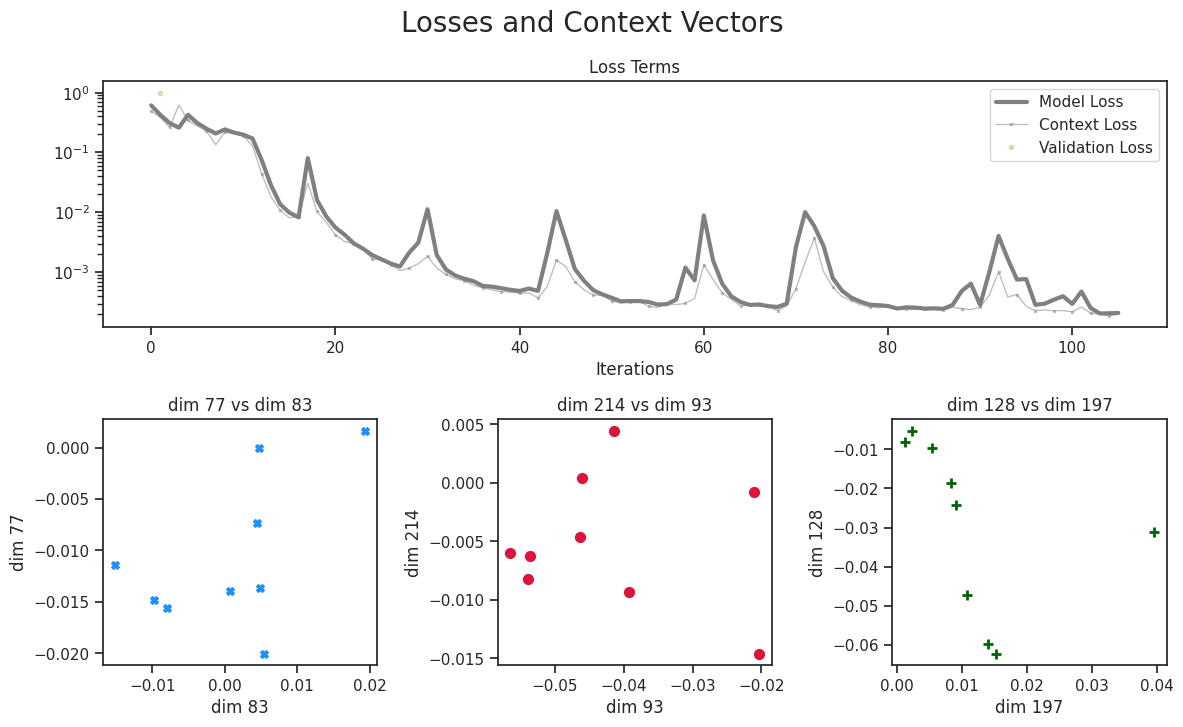

In [ ]:
#%%

## Test and visualise the results on a test dataloader
visualtester = DynamicsVisualTester(trainer, key=test_key)

ind_crit, all_ind_crit = visualtester.evaluate(train_dataloader, 
                                    taylor_order=taylor_orders[1], 
                                    nb_steps=nb_adapt_epochs,
                                    print_error_every=print_error_every, 
                                    criterion_id=0,
                                    verbose=True,
                                    val_dataloader=val_dataloader,
                                    max_ret_env_states=max_ret_env_states,
                                    max_adapt_batches=max_adapt_batches,
                                    stochastic=False)

visualtester.visualize_artefacts(save_path=run_folder+"artefacts.png")
print("Loss per InD environment:", all_ind_crit[0].tolist())



# new_ctx = np.load(run_folder+"contexts_params.npy")
# learner.contexts = eqx.tree_at(lambda c:c.params, learner.contexts, new_ctx)
# eqx.tree_serialise_leaves(run_folder+"contexts.eqx", learner.contexts)


==  Begining in-domain dynamics visualisation ... ==
    Trajectory id: 0
    Visualized dimensions: (0, 1)
    Using contexts from meta-training.
Testing finished. Figure saved in: ./runs/241019-183954-CoDAH-9Envs/dynamics.png


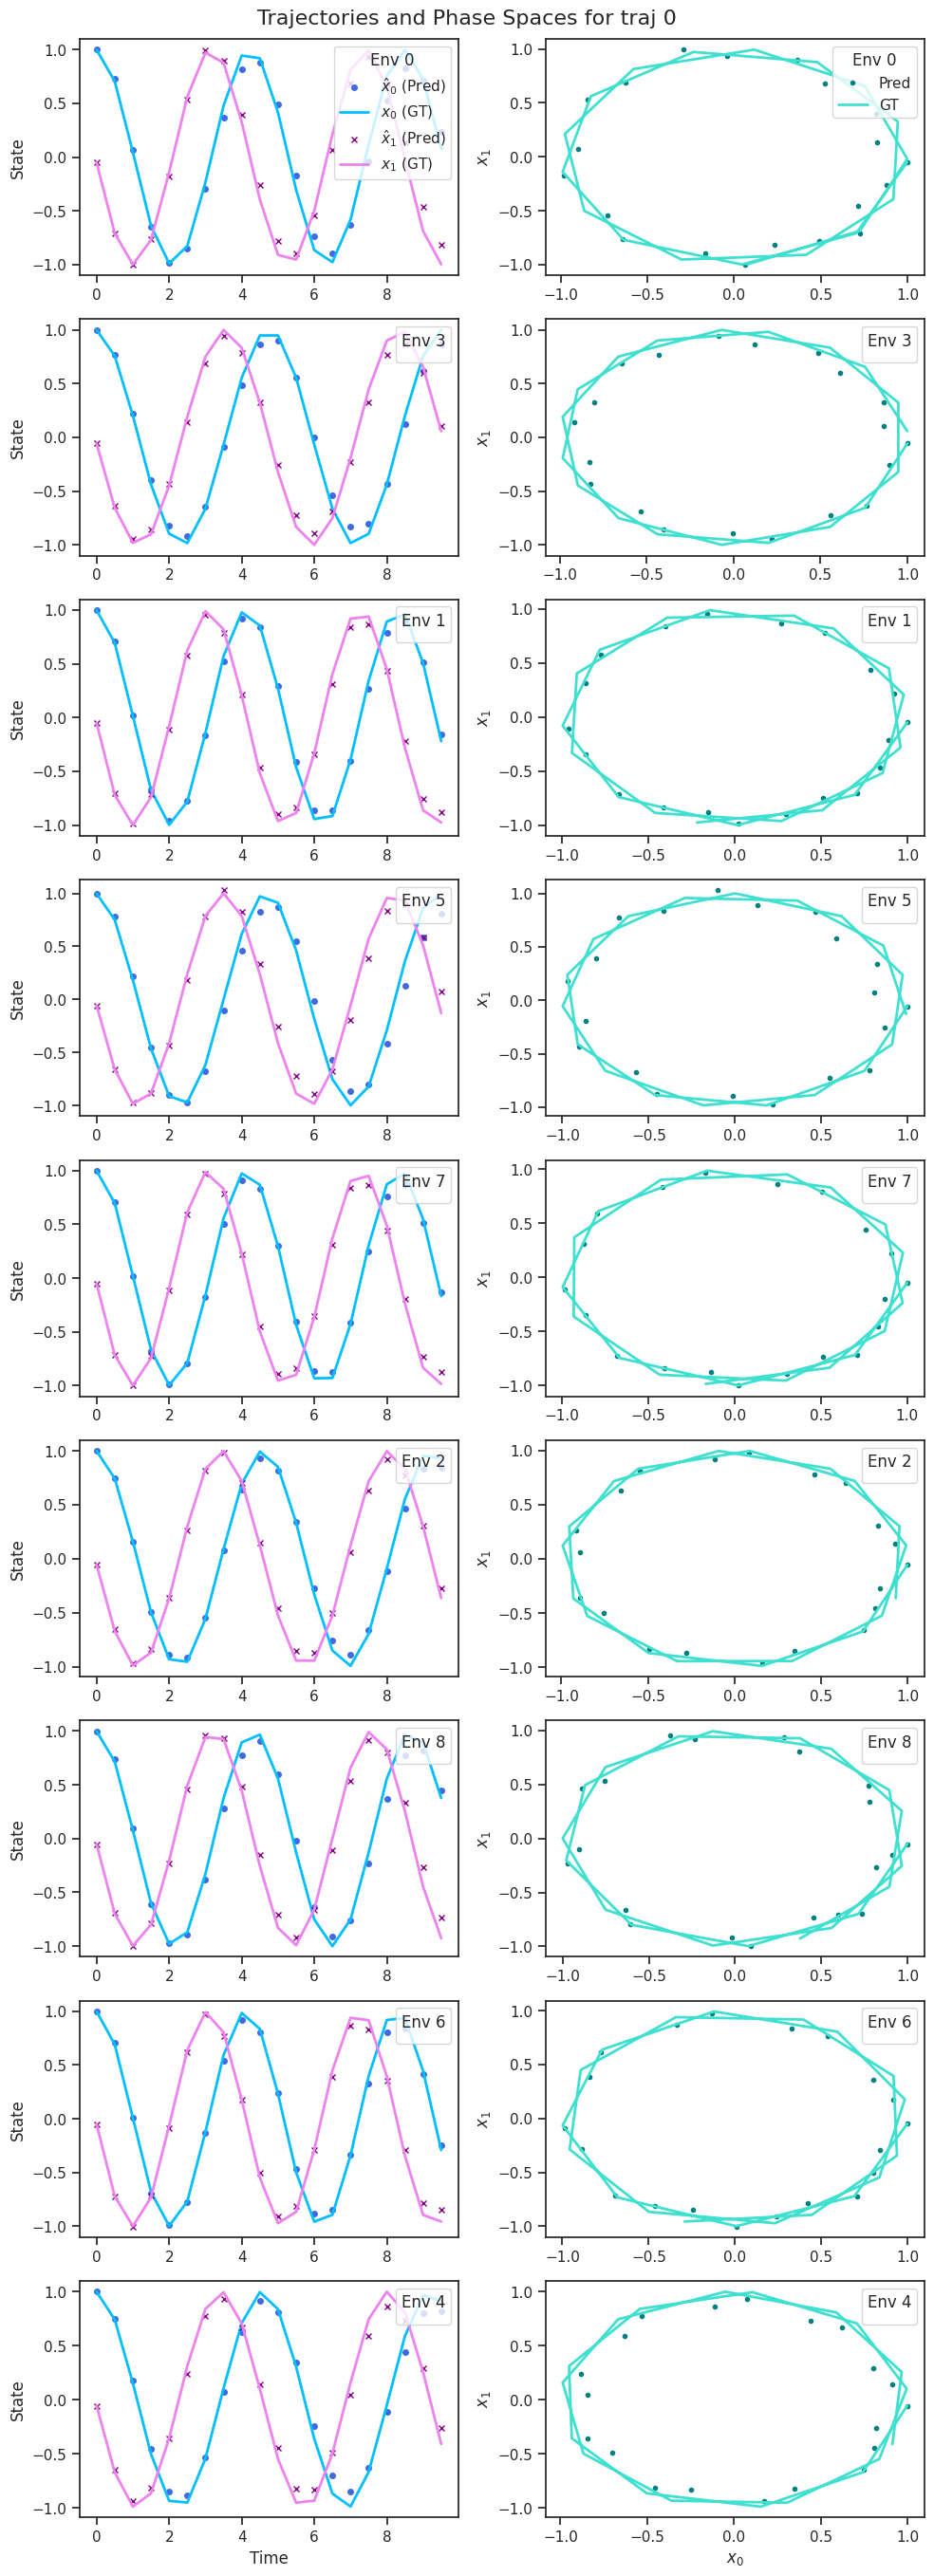

In [ ]:
#%%

visualtester.visualize_dynamics(save_path=run_folder+"dynamics.png",
                                data_loader=val_dataloader,
                                nb_envs=9,
                                # envs=[0, 2, 3, 5, 6, 7, 20, 49, 58, 66, 116, 202, 214, 232],
                                traj=0,
                                share_axes=False,
                                key=test_key)

In [ ]:
#%%

# learner.contexts.params
# learner.model.vectorfield.neuralnet.hyperlayer.weight
# learner.model.vectorfield.neuralnet.root_weights.shape

    Creating a new model with taylor order 0 ...
Using any previously defined optimizer for adapation

=== Beginning Meta-Testing ... ===
    Number of examples in a batch along envs: 112
    Maximum number of batches (along envs): 1
Epoch:   0      Batch:   0      Loss: 0.46385232     ContextsNorm: 0.00000000
Epoch:   1      Batch:   0      Loss: 0.44825876     ContextsNorm: 0.00000000
Epoch:   2      Batch:   0      Loss: 0.43311578     ContextsNorm: 0.00000000
Epoch:   3      Batch:   0      Loss: 0.41837743     ContextsNorm: 0.00000000
Epoch: 100      Batch:   0      Loss: 0.06958199     ContextsNorm: 0.00000000
Epoch: 200      Batch:   0      Loss: 0.05160651     ContextsNorm: 0.00000000
Epoch: 300      Batch:   0      Loss: 0.03674533     ContextsNorm: 0.00000000
Epoch: 400      Batch:   0      Loss: 0.02467652     ContextsNorm: 0.00000000
Epoch: 500      Batch:   0      Loss: 0.02084793     ContextsNorm: 0.00000000
Epoch: 600      Batch:   0      Loss: 0.01878436     ContextsNor

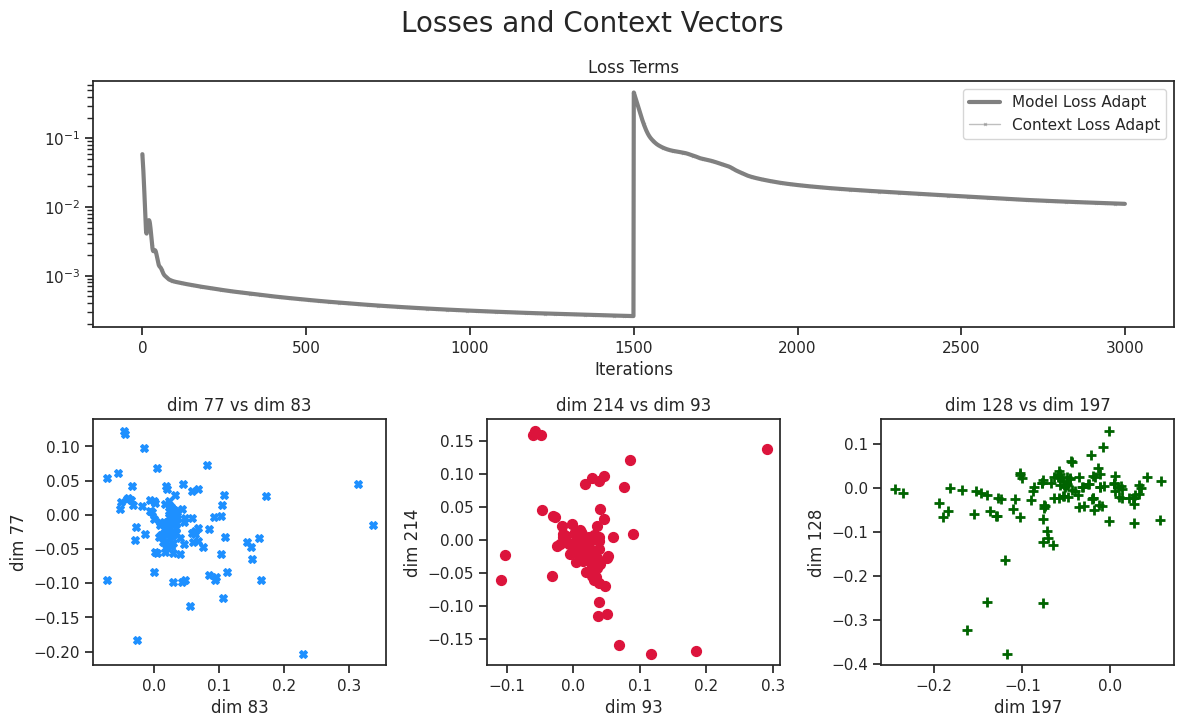

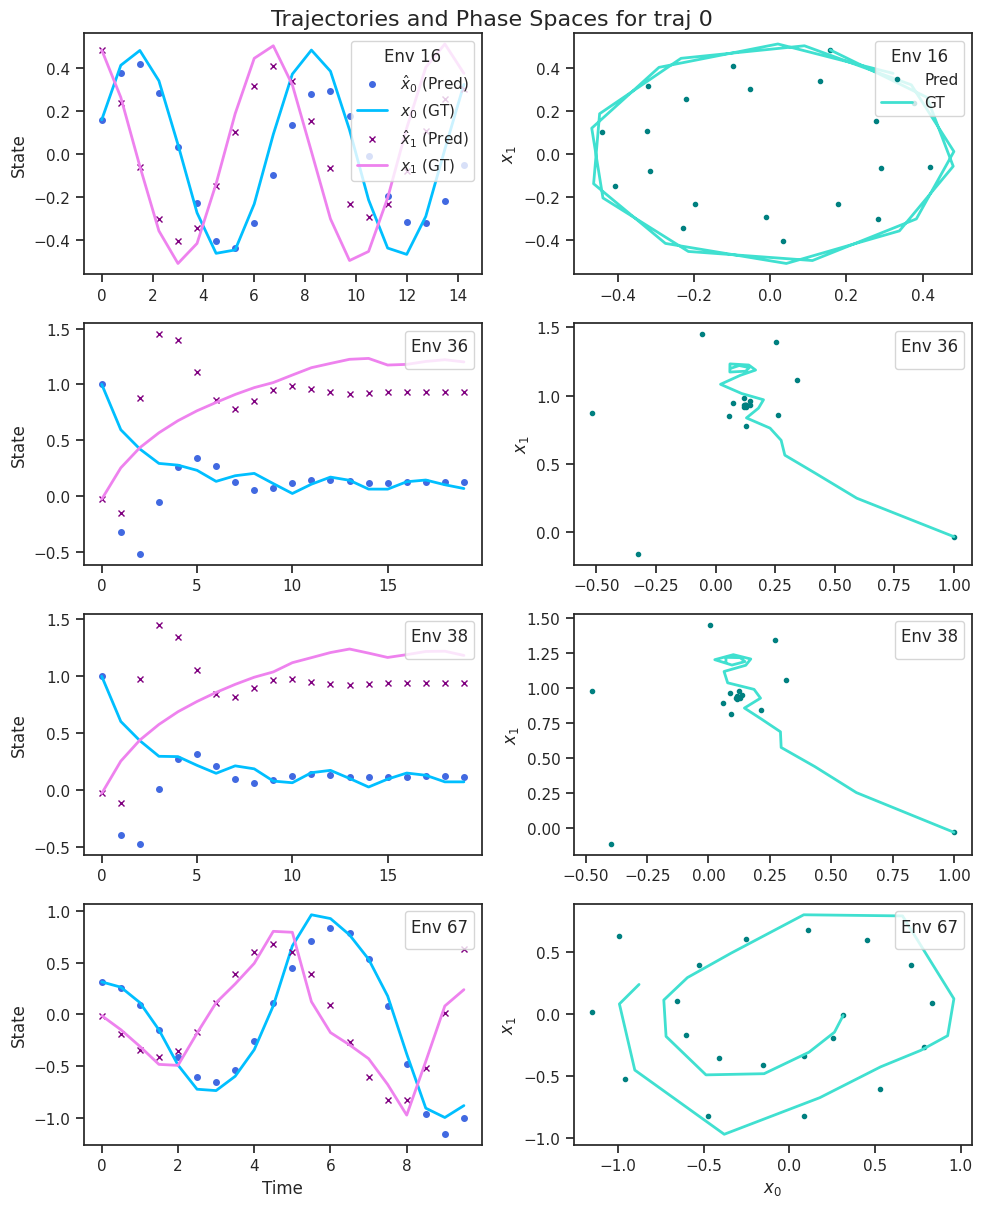

In [ ]:
#%%

## Adapt the model to the new dataset
if meta_test:
    adapt_dataloader = NumpyLoader(ODEBenchDataset(data_dir=data_folder+"adapt_train.npz", 
                                                   adaptation=True,
                                                   norm_consts=data_folder+"adapt_train_bounds.npy",
                                                   num_shots=num_shots[0], 
                                                   skip_steps=skip_steps,
                                                   traj_prop_min=train_proportion),
                                batch_size=num_envs[1], 
                                shuffle=shuffle,
                                num_workers=num_workers,
                                drop_last=False)

    adapt_dataloader_test = NumpyLoader(ODEBenchDataset(data_dir=data_folder+"adapt_test.npz", 
                                                        adaptation=True,
                                                        norm_consts=data_folder+"adapt_train_bounds.npy",
                                                        num_shots=num_shots[0], 
                                                        skip_steps=skip_steps,
                                                        traj_prop_min=test_proportion),
                                batch_size=num_envs[1],
                                shuffle=shuffle,
                                num_workers=num_workers,
                                drop_last=False)

    ood_crit, all_ood_crit = visualtester.evaluate(adapt_dataloader, 
                                        taylor_order=taylor_orders[1], 
                                        nb_steps=nb_adapt_epochs,
                                        print_error_every=print_error_every, 
                                        criterion_id=0,
                                        verbose=True,
                                        val_dataloader=adapt_dataloader_test,
                                        max_ret_env_states=max_ret_env_states,
                                        max_adapt_batches=max_adapt_batches,
                                        stochastic=False)
    print("Loss per OoD environment:", all_ood_crit[0].tolist())

    visualtester.visualize_artefacts(save_path=adapt_folder+"artefacts.png", adaptation=True)


    visualtester.visualize_dynamics(save_path=adapt_folder+"dynamics_ood.png",
                                    data_loader=adapt_dataloader_test,
                                    nb_envs=4,
                                    traj=0,
                                    share_axes=False,
                                    key=test_key)


==  Begining context clusters visualisation with t-SNE ... ==
    Visualising the parameters (either vectors or function weights)
    Visualising predictions from the contexts (reconstituted as functions)


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Saving context clusters in: ./runs/241019-183954-CoDAH-9Envs/context_clusters.png


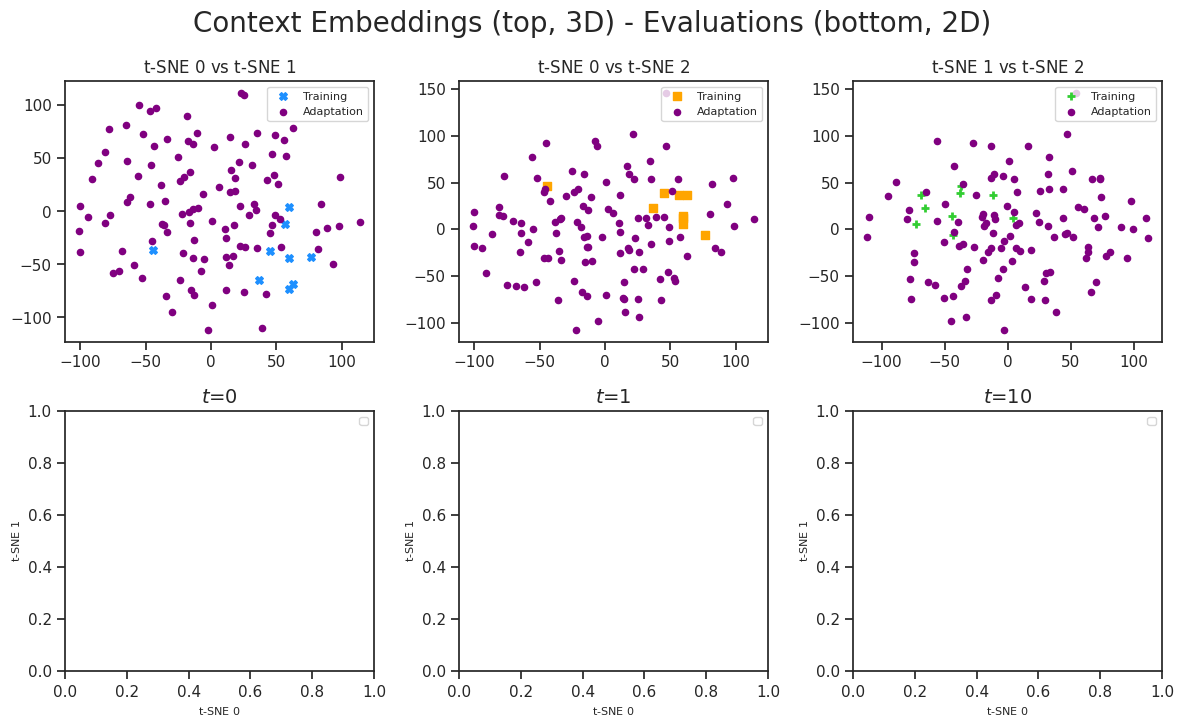

In [ ]:
#%%

visualtester.visualize_context_clusters(perplexities=(25, 20),
                                        # key=test_key,
                                        key=jax.random.PRNGKey(time.time_ns()),
                                        save_path=run_folder+"context_clusters.png")

In [ ]:
#%%

## After training, copy nohup.log to the runfolder
try:
    __IPYTHON__ ## in a jupyter notebook
except NameError:
    os.system(f"cp nohup.log {run_folder}")

In [ ]:
#%%

# adapt_dataloader_test.dataset.dataset.max()
# train_dataloader.dataset.dataset.max()
# val_dataloader.dataset.dataset.max()